In [1]:
# Import libraries

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
# Load files
retail = pd.read_csv("./output/Fed_DR.csv")
macro = pd.read_csv("./output/ccar_macro_data_quarterly.csv")

# Convert Date column
retail['Date'] = pd.to_datetime(retail['Quarter_dt'])
macro['Date'] = pd.to_datetime(macro['DATE'])

macro['Date'] = macro['Date'].dt.to_period('Q').dt.start_time

# Merge
df = pd.merge(retail, macro, on="Date", how="inner")

# Sort
df = df.sort_values("Date").reset_index(drop=True)

df

,Quarter_dt,Wholesale_Proxy_DR,Retail_Proxy_DR,Date,DATE,Unemployment_Rate,Real_GDP,BBB_Spread,VIX_Volatility_Index,10Y_Treasury_Yield,...,INDPRO_Growth,TCU_Change,Term_Spread_10Y_3M,RDI_YoY,RDI_Growth,10Y_Change,3M_Change,Prime_Change,BBB_Change,HY_Change
0,2000-01-01,0.0191,0.0436,2000-01-01,2000-03-31,4.033333,13878.147,1.609077,23.150317,6.468413,...,0.034620,-0.093700,0.948413,0.038635,0.069845,0.323574,0.476667,0.317460,-0.005251,0.080126
1,2000-04-01,0.0208,0.0449,2000-04-01,2000-06-30,3.933333,14130.908,2.139231,24.923968,6.184921,...,0.045337,0.149333,0.471587,0.050201,0.047278,-0.283492,0.193333,0.555556,0.530154,0.933385
2,2000-07-01,0.0218,0.0450,2000-07-01,2000-09-30,4.000000,14145.312,2.151515,19.169048,5.889841,...,-0.004291,-0.849700,-0.126825,0.056584,0.052796,-0.295079,0.303333,0.250000,0.012284,0.353748
3,2000-10-01,0.0237,0.0448,2000-10-01,2000-12-31,3.900000,14229.765,2.496923,26.016667,5.570645,...,-0.010533,-0.982967,-0.446022,0.050059,0.026782,-0.319196,0.000000,0.000000,0.345408,1.801483
4,2001-01-01,0.0259,0.0467,2001-01-01,2001-03-31,4.233333,14183.120,2.422154,25.726452,5.044194,...,-0.047285,-1.720800,0.227527,0.040259,0.031859,-0.526452,-1.200000,-0.879032,-0.074769,-0.111846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,2024-07-01,0.0109,0.0308,2024-07-01,2024-09-30,4.166667,23478.570,1.198358,17.066667,3.954687,...,-0.023648,-0.649700,-1.035312,0.028140,0.012278,-0.494043,-0.253333,-0.062500,0.064116,0.079699
99,2024-10-01,0.0120,0.0297,2024-10-01,2024-12-31,4.133333,23586.542,1.032121,17.363231,4.275484,...,-0.014999,-0.522500,-0.124516,0.024492,0.019810,0.320796,-0.590000,-0.614423,-0.166237,-0.463184
100,2025-01-01,0.0118,0.0293,2025-01-01,2025-03-31,4.133333,23548.210,1.060000,18.521111,4.453607,...,0.041661,0.520000,0.243607,0.019716,0.022388,0.178123,-0.190000,-0.323077,0.027879,0.070317
101,2025-04-01,0.0118,0.0292,2025-04-01,2025-06-30,4.200000,23770.976,1.231231,23.561406,4.361774,...,0.018100,0.065600,0.131774,0.018321,0.018317,-0.091832,0.020000,0.000000,0.171231,0.633170


In [3]:
## Create Dependent variable - Logit transform of DR

# Avoid log(0)
epsilon = 1e-6
df['DR_adj'] = df['Retail_Proxy_DR'].clip(epsilon, 1 - epsilon)

# Logit transform
df['logit_DR'] = np.log(df['DR_adj'] / (1 - df['DR_adj']))

In [4]:
## Create 1-quarter lagged macro variables

lag_vars = [
    'Unemployment_Rate',
    'CPI_Inflation',
    'Real_Disposable_Income',
    'Prime_Rate',
    'Real_GDP_Growth'
]

for var in lag_vars:
    df[f'{var}_lag1'] = df[var].shift(1)

# Lagged dependent variable (persistence)
df['logit_DR_lag1'] = df['logit_DR'].shift(1)

# Drop NA after lag
df = df.dropna().reset_index(drop=True)

In [ ]:
## Modeling change instead of level as above model shows high persistence and is economically wrong

df['d_logit_DR'] = df['logit_DR'].diff()
df['d_Unemployment'] = df['Unemployment_Rate'].diff()
df['d_CPI'] = df['CPI_Inflation'].diff()
df['d_Prime'] = df['Prime_Rate'].diff()
df['d_GDP_Growth'] = df['Real_GDP_Growth'].diff()
df['d_BBB_Spread'] = df['BBB_Spread'].diff()

# Lagging differenced variables
df['d_Unemployment_lag1'] = df['d_Unemployment'].shift(1)
df['d_Unemployment_lag2'] = df['d_Unemployment'].shift(2)


In [ ]:
df['d_logit_DR'] = df['logit_DR'].diff()
df['d_logit_DR_lag1'] = df['d_logit_DR'].shift(1)


In [7]:
## Model is breaking because of COVID period, so adding a COVID dummy

# df['COVID_dummy'] = 0
# df.loc[(df['Date'] >= '2020-01-01') & (df['Date'] <= '2021-12-31'), 'COVID_dummy'] = 1

Long Run Model
                            OLS Regression Results                            
Dep. Variable:               logit_DR   R-squared:                       0.697
Model:                            OLS   Adj. R-squared:                  0.688
Method:                 Least Squares   F-statistic:                     73.00
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           1.43e-24
Time:                        22:11:15   Log-Likelihood:                 14.246
No. Observations:                  99   AIC:                            -20.49
Df Residuals:                      95   BIC:                            -10.11
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -3

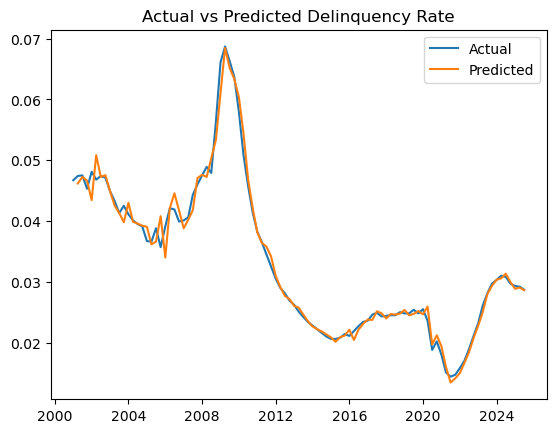

In [8]:
## Fed Style Error Correction Model


# df['d_unemp_avg'] = (
#     df['d_Unemployment'] +
#     df['d_Unemployment_lag1'] +
#     df['d_Unemployment_lag2']
# )/3

df_model = df.dropna().copy()

############################################
# STEP 1 — Long Run Equilibrium Regression
############################################

X_long = df_model[['Unemployment_Rate',
                   'Prime_Rate',
                   'CPI_Inflation']]

X_long = sm.add_constant(X_long)

long_run = sm.OLS(df_model['logit_DR'], X_long).fit()

print("Long Run Model")
print(long_run.summary())

############################################
# STEP 2 — Error Correction Term
############################################

df_model['ec_term'] = long_run.resid
df_model['ec_term_lag1'] = df_model['ec_term'].shift(1)

############################################
# STEP 3 — Short Run ECM Model
############################################

X_short = df_model[[
    # 'd_Unemployment',
    'd_Unemployment_lag1',
    'd_Unemployment_lag2',
    # 'd_unemp_avg',
    'd_Prime',
    'd_BBB_Spread',
    'd_logit_DR_lag1',
    'ec_term_lag1'
]]

X_short = sm.add_constant(X_short)

y = df_model['d_logit_DR']

ecm_model = sm.OLS(y, X_short, missing='drop').fit()

print("\nShort Run ECM Model")
print(ecm_model.summary())

############################################
# STEP 4 — Predict Δlogit(PD)
############################################

df_model['pred_d_logit'] = ecm_model.predict(X_short)

############################################
# STEP 5 — Rebuild logit(PD)
############################################

df_model['pred_logit'] = df_model['logit_DR_lag1'] + df_model['pred_d_logit']

############################################
# STEP 6 — Convert to PD
############################################

df_model['pred_PD'] = np.exp(df_model['pred_logit']) / (1 + np.exp(df_model['pred_logit']))

############################################
# STEP 7 — Compare actual vs predicted
############################################

comparison = df_model[['Retail_Proxy_DR','pred_PD']]

print(comparison.tail())

plt.figure()
plt.plot(df_model['Date'], df_model['Retail_Proxy_DR'], label='Actual')
plt.plot(df_model['Date'], df_model['pred_PD'], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Delinquency Rate")
plt.show()

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Select only explanatory variables used in the short-run model
X_vif = df_model[[
'd_Unemployment_lag1',
'd_Unemployment_lag2',
'd_Prime',
'd_BBB_Spread',
'd_logit_DR_lag1',
'ec_term_lag1'
]]

# Drop rows with NaN or inf
X_vif = X_vif.replace([np.inf, -np.inf], np.nan).dropna()

# Add constant
X_vif = sm.add_constant(X_vif)

# Calculate VIF
vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif)

              Variable       VIF
0                const  1.007270
1  d_Unemployment_lag1  1.103679
2  d_Unemployment_lag2  1.143983
3              d_Prime  1.148859
4         d_BBB_Spread  1.129306
5      d_logit_DR_lag1  1.224151
6         ec_term_lag1  1.158789


In [10]:
## Functions to convert between logit and PD

def logit_to_pd(x):
    return 1 / (1 + np.exp(-x))

def pd_to_logit(p):
    return np.log(p / (1 - p))

In [11]:
# Long-run coefficients
lr = {
    "const": -3.3403,
    "unemp": 0.1047,
    "prime": 0.1354,
    "cpi": -0.0058
}

# Short-run ECM coefficients
sr = {
    "const": -0.0014,
    "d_unemp_l1": -0.0123,
    "d_unemp_l2": 0.0244,
    "d_prime": 0.0222,
    "d_bbb": 0.0443,
    "d_logit_l1": 0.6393,
    "ec_l1": -0.0211
}

In [12]:
## Forecasting function using ECM model
def forecast_pd(df_hist, scenario_df, horizon=13):
    
    df = scenario_df.copy().reset_index(drop=True)
    
    # Initialize columns
    df["logit_DR"] = np.nan
    df["PD"] = np.nan
    df["d_logit_DR"] = np.nan
    
    # Last observed values from history
    last = df_hist.iloc[-1]
    last_minus_1 = df_hist.iloc[-2]
    last_minus_2 = df_hist.iloc[-3]
    
    logit_prev = last["logit_DR"]
    unemp_prev = last["Unemployment_Rate"]
    unemp_prev_lag1 = last_minus_1["Unemployment_Rate"]
    prime_prev = last["Prime_Rate"]
    bbb_prev = last["BBB_Spread"]
    

    # Initialize lagged differences from history
    d_logit_l1 = last["d_logit_DR"]  # or .diff().iloc[-1] if d_logit_DR not in df_hist
    d_unemp_l1 = unemp_prev - unemp_prev_lag1  # Most recent change
    d_unemp_l2 = unemp_prev_lag1 - last_minus_2["Unemployment_Rate"]  # Change from 2 periods ago
    
    for t in range(len(df)):
        
        unemp = df.loc[t, "Unemployment_Rate"]
        prime = df.loc[t, "Prime_Rate"]
        cpi = df.loc[t, "CPI_Inflation"]
        bbb = df.loc[t, "BBB_Spread"]
        
        # Long-run equilibrium (cointegration relationship)
        logit_lr = (
            lr["const"]
            + lr["unemp"] * unemp
            + lr["prime"] * prime
            + lr["cpi"] * cpi
        )
        
        # Error correction term (deviation from equilibrium)
        ec_lag1 = logit_prev - logit_lr
        
        # *** FIXED: Compute first differences correctly ***
        d_unemp_current = unemp - unemp_prev
        d_prime = prime - prime_prev
        d_bbb = bbb - bbb_prev
        
        # Short-run dynamics
        d_logit = (
            sr["const"]
            + sr["d_unemp_l1"] * d_unemp_l1
            + sr["d_unemp_l2"] * d_unemp_l2
            + sr["d_prime"] * d_prime
            + sr["d_bbb"] * d_bbb
            + sr["d_logit_l1"] * d_logit_l1
            + sr["ec_l1"] * ec_lag1
        )
        
        # Update level
        logit_curr = logit_prev + d_logit
        
        # Store results
        df.loc[t, "d_logit_DR"] = d_logit
        df.loc[t, "logit_DR"] = logit_curr
        df.loc[t, "PD"] = logit_to_pd(logit_curr)
        
        # *** FIXED: Update lags correctly for next iteration ***
        logit_prev = logit_curr
        d_logit_l1 = d_logit
        
        # Shift unemployment lags
        d_unemp_l2 = d_unemp_l1  # This period's lag1 becomes next period's lag2
        d_unemp_l1 = d_unemp_current  # Current change becomes next period's lag1
        
        # Update levels for next iteration
        unemp_prev = unemp
        prime_prev = prime
        bbb_prev = bbb
    
    return df

In [20]:
## Get scenarios
# File paths
baseline_path = "raw_data/2026_Final_Supervisory_Baseline_Domestic.csv"
adverse_path = "raw_data/2026_Final_Supervisory_Severely_Adverse_Domestic.csv"

# Load data
baseline = pd.read_csv(baseline_path)
adverse = pd.read_csv(adverse_path)

# Standardize and prepare scenario data
def prepare_scenario(df, scenario_name):
    
    df = df.copy()
    
    # Rename columns
    df = df.rename(columns={
        "Date": "date",
        "Unemployment rate": "Unemployment_Rate",
        "Prime rate": "Prime_Rate",
        "CPI inflation rate": "CPI_Inflation",
        "BBB corporate yield": "BBB_Spread",         
    })
    
    # Convert date
    df[["year", "quarter"]] = df["date"].str.split(" ", expand=True)
    df["quarter"] = df["quarter"].str.replace("Q", "").astype(int)
    
    df["date"] = pd.PeriodIndex.from_fields(
        year=df["year"].astype(int),
        quarter=df["quarter"],
        freq="Q"
    ).to_timestamp(how="start")
    
    # Keep only relevant columns
    cols = ["date", "Unemployment_Rate", "Prime_Rate", "CPI_Inflation", "BBB_Spread"]
    df = df[cols]
    
    # *** NEW: Compute first differences ***
    df['d_Unemployment'] = df['Unemployment_Rate'].diff()
    df['d_Prime'] = df['Prime_Rate'].diff()
    df['d_CPI'] = df['CPI_Inflation'].diff()
    df['d_BBB_Spread'] = df['BBB_Spread'].diff()
    
    # *** NEW: Compute lagged differences ***
    df['d_Unemployment_lag1'] = df['d_Unemployment'].shift(1)
    df['d_Unemployment_lag2'] = df['d_Unemployment'].shift(2)
    df['d_Prime_lag1'] = df['d_Prime'].shift(1)
    df['d_BBB_Spread_lag1'] = df['d_BBB_Spread'].shift(1)
    
    # Add scenario label
    df["scenario"] = scenario_name
    
    return df

baseline = prepare_scenario(baseline, "baseline")
adverse = prepare_scenario(adverse, "severely_adverse")

# print(baseline.head())
# print(adverse.head())

# Forecast
baseline_forecast = forecast_pd(df, baseline)
adverse_forecast = forecast_pd(df, adverse)

print(baseline_forecast.head())
print(adverse_forecast.head())

        date  Unemployment_Rate  Prime_Rate  CPI_Inflation  BBB_Spread  \
0 2026-01-01                4.6         6.6            3.0         5.2   
1 2026-04-01                4.6         6.4            2.7         5.3   
2 2026-07-01                4.6         6.2            2.6         5.3   
3 2026-10-01                4.5         6.1            2.5         5.4   
4 2027-01-01                4.5         6.1            2.5         5.4   

   d_Unemployment  d_Prime  d_CPI  d_BBB_Spread  d_Unemployment_lag1  \
0             NaN      NaN    NaN           NaN                  NaN   
1             0.0     -0.2   -0.3           0.1                  NaN   
2             0.0     -0.2   -0.1           0.0                  0.0   
3            -0.1     -0.1   -0.1           0.1                  0.0   
4             0.0      0.0    0.0           0.0                 -0.1   

   d_Unemployment_lag2  d_Prime_lag1  d_BBB_Spread_lag1  scenario  logit_DR  \
0                  NaN           NaN       

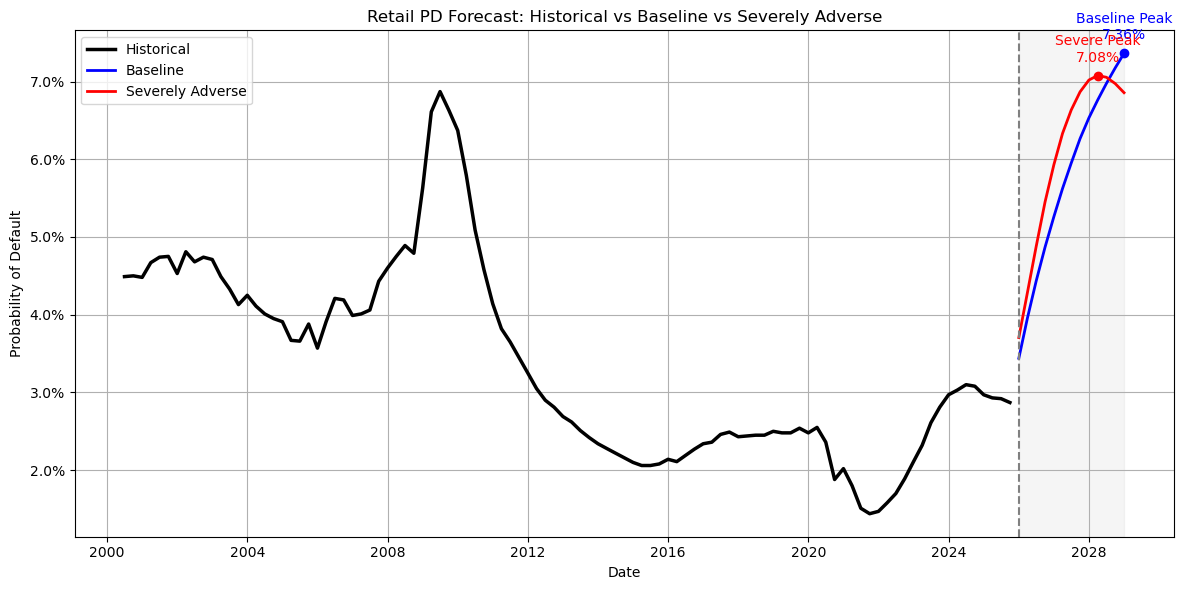

In [19]:
# Historical PD 
hist = df.copy()

# Use DATE (already quarter end aligned)
hist["date"] = pd.to_datetime(hist["DATE"])

# Use PD directly
hist["PD"] = hist["Retail_Proxy_DR"]

# Keep clean structure
hist = hist[["date", "PD"]].dropna()
hist["type"] = "Historical"

# hist["PD"] = hist["Retail_Proxy_DR"]

baseline_plot = baseline_forecast[["date", "PD"]].copy()
baseline_plot["type"] = "Baseline"

adverse_plot = adverse_forecast[["date", "PD"]].copy()
adverse_plot["type"] = "Severely Adverse"

plot_df = pd.concat([hist, baseline_plot, adverse_plot], ignore_index=True)

# Sort for clean plotting
plot_df = plot_df.sort_values("date")

plt.figure(figsize=(12,6))

# --- Plot Historical ---
plt.plot(
    hist["date"], hist["PD"],
    color="black", linewidth=2.5, label="Historical"
)

# --- Plot Baseline ---
plt.plot(
    baseline_plot["date"], baseline_plot["PD"],
    color="blue", linewidth=2, label="Baseline"
)

# --- Plot Severely Adverse ---
plt.plot(
    adverse_plot["date"], adverse_plot["PD"],
    color="red", linewidth=2, label="Severely Adverse"
)

# --- Forecast start marker ---
forecast_start = baseline_plot["date"].min()
plt.axvline(forecast_start, linestyle="--", color="gray")

# --- Highlight forecast region ---
plt.axvspan(forecast_start, plot_df["date"].max(), alpha=0.08, color="gray")

# =========================
# 🔥 Peak PD Annotations
# =========================

# Baseline peak
baseline_peak_idx = baseline_plot["PD"].idxmax()
baseline_peak_date = baseline_plot.loc[baseline_peak_idx, "date"]
baseline_peak_val = baseline_plot.loc[baseline_peak_idx, "PD"]

plt.scatter(baseline_peak_date, baseline_peak_val, color="blue")
plt.annotate(
    f"Baseline Peak\n{baseline_peak_val:.2%}",
    (baseline_peak_date, baseline_peak_val),
    textcoords="offset points",
    xytext=(0,10),
    ha='center',
    color="blue"
)

# Severe peak
adverse_peak_idx = adverse_plot["PD"].idxmax()
adverse_peak_date = adverse_plot.loc[adverse_peak_idx, "date"]
adverse_peak_val = adverse_plot.loc[adverse_peak_idx, "PD"]

plt.scatter(adverse_peak_date, adverse_peak_val, color="red")
plt.annotate(
    f"Severe Peak\n{adverse_peak_val:.2%}",
    (adverse_peak_date, adverse_peak_val),
    textcoords="offset points",
    xytext=(0,10),
    ha='center',
    color="red"
)

# --- Labels ---
plt.title("Retail PD Forecast: Historical vs Baseline vs Severely Adverse")
plt.xlabel("Date")
plt.ylabel("Probability of Default")

# Format y-axis as %
plt.gca().yaxis.set_major_formatter(lambda x, _: f"{x:.1%}")

plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("pd_forecast.png", dpi=300)
plt.show()

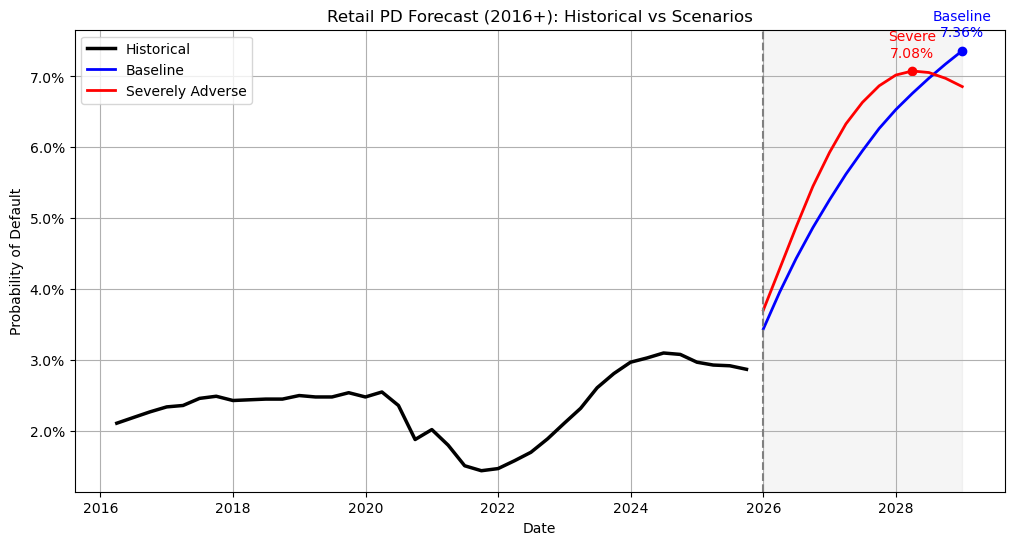

In [15]:
cutoff_date = "2016-01-01"

hist_plot = hist[hist["date"] >= cutoff_date]
baseline_plot_f = baseline_plot[baseline_plot["date"] >= cutoff_date]
adverse_plot_f  = adverse_plot[adverse_plot["date"] >= cutoff_date]

plt.figure(figsize=(12,6))

# --- Historical ---
plt.plot(
    hist_plot["date"], hist_plot["PD"],
    color="black", linewidth=2.5, label="Historical"
)

# --- Baseline ---
plt.plot(
    baseline_plot_f["date"], baseline_plot_f["PD"],
    color="blue", linewidth=2, label="Baseline"
)

# --- Severely Adverse ---
plt.plot(
    adverse_plot_f["date"], adverse_plot_f["PD"],
    color="red", linewidth=2, label="Severely Adverse"
)

# --- Forecast start ---
forecast_start = baseline_plot["date"].min()
plt.axvline(forecast_start, linestyle="--", color="gray")

# --- Highlight forecast region ---
plt.axvspan(forecast_start, adverse_plot_f["date"].max(), alpha=0.08, color="gray")

# =========================
# 🔥 Peak Annotations (unchanged logic, but use filtered data)
# =========================

# Baseline peak
b_idx = baseline_plot_f["PD"].idxmax()
b_date = baseline_plot_f.loc[b_idx, "date"]
b_val = baseline_plot_f.loc[b_idx, "PD"]

plt.scatter(b_date, b_val, color="blue")
plt.annotate(
    f"Baseline\n{b_val:.2%}",
    (b_date, b_val),
    textcoords="offset points",
    xytext=(0,10),
    ha='center',
    color="blue"
)

# Severe peak
a_idx = adverse_plot_f["PD"].idxmax()
a_date = adverse_plot_f.loc[a_idx, "date"]
a_val = adverse_plot_f.loc[a_idx, "PD"]

plt.scatter(a_date, a_val, color="red")
plt.annotate(
    f"Severe\n{a_val:.2%}",
    (a_date, a_val),
    textcoords="offset points",
    xytext=(0,10),
    ha='center',
    color="red"
)

# --- Labels ---
plt.title("Retail PD Forecast (2016+): Historical vs Scenarios")
plt.xlabel("Date")
plt.ylabel("Probability of Default")

plt.gca().yaxis.set_major_formatter(lambda x, _: f"{x:.1%}")

plt.legend()
plt.grid()

plt.show()

In [21]:
## Save forecast data for reporting

baseline_forecast.to_csv("./output/retail_pd_baseline_forecast.csv", index=False)
adverse_forecast.to_csv("./output/retail_pd_adverse_forecast.csv", index=False)